# Test word search in the documents

In [ ]:
import os
import re
import unicodedata
from itertools import zip_longest
import PyPDF2
import matplotlib.pyplot as plt
import numpy as np

# Configuration
max_pages = 3
path_npdes = 'output/2025-10-8-test1/NPDES'
path_non_npdes = 'output/2025-10-8-test1/Not-NPDES'
path_info = 'output/2025-10-8-test1/info'
out_dir = 'output/2025-10-8-test1'
os.makedirs(out_dir, exist_ok=True)


def normalize_text(s: str) -> str:
    """Basic unicode normalization and removal of soft/zero-width chars; lowercased."""
    if not s:
        return ''
    s = unicodedata.normalize('NFKC', s)
    s = s.replace('\u00AD', '')  # soft hyphen
    s = s.replace('\u200B', '')  # zero width space
    s = s.replace('\u00A0', ' ')  # NBSP -> space
    # collapse whitespace to single spaces
    s = re.sub(r'\s+', ' ', s)
    return s.strip().lower()


def search_keywords(folder_path, keyword, max_pages):
    """
    For each PDF in folder_path, extract text from the first `max_pages` pages,
    normalize it, remove ALL spaces (to handle extractors that insert spurious
    spaces inside words), and then count occurrences of the keyword with its
    spaces removed as well.

    Returns: list[int] with one count per PDF (order: sorted(os.listdir(folder_path))
    considering only .pdf files).
    """
    occurrences = []
    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}")
        return occurrences

    filenames = sorted([f for f in os.listdir(folder_path) if f.lower().endswith('.pdf')])
    for filename in filenames:
        file_path = os.path.join(folder_path, filename)

        # collect page text
        page_texts = []
        try:
            with open(file_path, 'rb') as f:
                try:
                    reader = PyPDF2.PdfReader(f)
                except Exception as e_open:
                    # Try pdfminer fallback if PyPDF2 cannot open
                    try:
                        from pdfminer.high_level import extract_text
                        text = extract_text(file_path, maxpages=max_pages)
                        if text:
                            page_texts = [text]
                    except Exception:
                        page_texts = []
                else:
                    num_pages = min(len(reader.pages), max_pages)
                    for page_num in range(num_pages):
                        try:
                            page = reader.pages[page_num]
                            text = page.extract_text() or ''
                        except Exception:
                            text = ''
                        if text:
                            page_texts.append(text)
        except Exception:
            page_texts = []

        combined = ' '.join(page_texts)
        normalized = normalize_text(combined)

        # Remove ALL spaces from the extracted text for the search
        spaceless_text = re.sub(r'\s+', '', normalized)

        # Prepare the keyword: normalize then remove spaces
        k_norm = normalize_text(keyword)
        k_spaceless = re.sub(r'\s+', '', k_norm)

        # Count occurrences in the spaceless text
        count = 0
        if k_spaceless:
            count = spaceless_text.count(k_spaceless)

        occurrences.append(count)

    return occurrences


def analyze_and_plot(npdes_occurrences, non_npdes_occurrences, info_occurrences, word, out_dir, max_pages):
    """Compute simple stats and plot grouped bincount bars."""
    def safe_stats(lst):
        if not lst:
            return 0, 0, 0.0, 0
        return min(lst), max(lst), float(np.mean(lst)), len(lst)

    np_min, np_max, np_mean, np_len = safe_stats(npdes_occurrences)
    nn_min, nn_max, nn_mean, nn_len = safe_stats(non_npdes_occurrences)
    i_min, i_max, i_mean, i_len = safe_stats(info_occurrences)

    print(f"NPDES occurrences: count={np_len}, min={np_min}, max={np_max}, mean={np_mean:.2f}")
    print(f"Not-NPDES occurrences: count={nn_len}, min={nn_min}, max={nn_max}, mean={nn_mean:.2f}")
    print(f"Info occurrences: count={i_len}, min={i_min}, max={i_max}, mean={i_mean:.2f}")

    overall_max = max(np_max, nn_max, i_max)
    xs = np.arange(overall_max + 1)

    bincounts = []
    sizes = []
    lists = [
        (npdes_occurrences, 'NPDES', 'blue'),
        (non_npdes_occurrences, 'Not-NPDES', 'red'),
        (info_occurrences, 'Info', 'green'),
    ]
    for lst, label, color in lists:
        if lst:
            bc = np.bincount(lst, minlength=overall_max + 1)
        else:
            bc = np.zeros(overall_max + 1, dtype=int)
        bincounts.append((bc, label, color))
        sizes.append(len(lst))

    width = 0.25
    fig, ax = plt.subplots(figsize=(10, 6))
    n_groups = len(bincounts)
    for i, (bc, label, color) in enumerate(bincounts):
        offset = (i - (n_groups-1)/2) * width
        ax.bar(xs + offset, bc, width=width, label=f"{label} (n={sizes[i]})", color=color, edgecolor='black', alpha=0.9)

    ax.set_xlabel(f'Number of occurrences of "{word}" in first {max_pages} pages (spaceless match)')
    ax.set_ylabel('Number of documents (PDFs)')
    ax.set_title(f'Distribution of occurrences of "{word}" in documents (spaceless search)')
    ax.set_xticks(xs)
    ax.set_xticklabels([str(x) for x in xs])
    ax.grid(axis='y', alpha=0.75)
    ax.legend()
    plt.tight_layout()

    out_path = os.path.join(out_dir, f"{word.replace(' ', '_')}_occurrences_histogram_spaceless.png")
    plt.savefig(out_path)
    try:
        plt.show()
    except Exception:
        pass
    plt.close()
    print(f"Saved histogram to {out_path}")


# Example: search for a single word (spaceless match)
word = 'The following Discharger is subject to waste discharge requirements'
print(f"Analyzing occurrences of the word (spaceless): {word}")
npdes_occurrences = search_keywords(path_npdes, word, max_pages)
non_npdes_occurrences = search_keywords(path_non_npdes, word, max_pages)
info_occurrences = search_keywords(path_info, word, max_pages)
analyze_and_plot(npdes_occurrences, non_npdes_occurrences, info_occurrences, word, out_dir, max_pages)


Analyzing occurrences of the word: NPDES


unknown widths : 
[0, IndirectObject(14094, 0, 136768353614000)]
unknown widths : 
[0, IndirectObject(14089, 0, 136768353614000)]
unknown widths : 
[0, IndirectObject(14084, 0, 136768353614000)]
unknown widths : 
[0, IndirectObject(14079, 0, 136768353614000)]
unknown widths : 
[0, IndirectObject(14089, 0, 136768353614000)]
unknown widths : 
[0, IndirectObject(14084, 0, 136768353614000)]
unknown widths : 
[0, IndirectObject(14079, 0, 136768353614000)]
unknown widths : 
[0, IndirectObject(15704, 0, 136768353614000)]
unknown widths : 
[0, IndirectObject(15704, 0, 136768353614000)]
unknown widths : 
[0, IndirectObject(15704, 0, 136768353614704)]
unknown widths : 
[0, IndirectObject(15704, 0, 136768353614704)]


NPDES occurrences: count=256, min=0, max=8, mean=4.57
Not-NPDES occurrences: count=144, min=0, max=15, mean=3.49
Info occurrences: count=17, min=0, max=6, mean=2.59


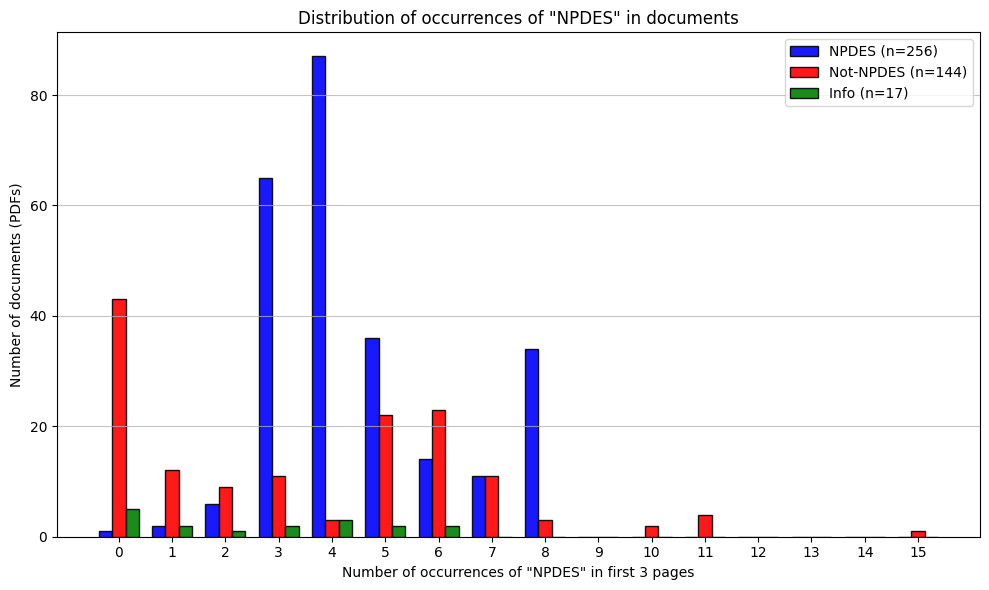

Saved histogram to output/2025-10-8-test1/NPDES_occurrences_histogram.png


In [13]:
out_dir = 'output/2025-10-8-test1'
os.makedirs(out_dir, exist_ok=True)

word = 'NPDES'
print(f"Analyzing occurrences of the word: {word}")
npdes_occurrences = search_keywords(path_npdes, word, max_pages)
non_npdes_occurrences = search_keywords(path_non_npdes, word, max_pages)
info_occurrences = search_keywords(path_info, word, max_pages)
analyze_and_plot(npdes_occurrences, non_npdes_occurrences, info_occurrences, word, out_dir, max_pages)

In [14]:
for i, nb in enumerate (npdes_occurrences):
    if nb == 0:
        pdf_file_name = sorted(os.listdir(path_npdes))[i]
        print(f"NPDES PDF with zero occurrences: {pdf_file_name}")

NPDES PDF with zero occurrences: R8-2022-0050_WDR_OCWD_GWRS.pdf


Analyzing occurrences of the word: The following Permittee is subject to waste discharge requirements


unknown widths : 
[0, IndirectObject(14094, 0, 137369941085712)]
unknown widths : 
[0, IndirectObject(14089, 0, 137369941085712)]
unknown widths : 
[0, IndirectObject(14084, 0, 137369941085712)]
unknown widths : 
[0, IndirectObject(14079, 0, 137369941085712)]
unknown widths : 
[0, IndirectObject(14089, 0, 137369941085712)]
unknown widths : 
[0, IndirectObject(14084, 0, 137369941085712)]
unknown widths : 
[0, IndirectObject(14079, 0, 137369941085712)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941085712)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941085712)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941088176)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941088176)]


0.078125
Analyzing occurrences of the word: The following Permittees are subject to waste discharge requirements


unknown widths : 
[0, IndirectObject(14094, 0, 137369941086944)]
unknown widths : 
[0, IndirectObject(14089, 0, 137369941086944)]
unknown widths : 
[0, IndirectObject(14084, 0, 137369941086944)]
unknown widths : 
[0, IndirectObject(14079, 0, 137369941086944)]
unknown widths : 
[0, IndirectObject(14089, 0, 137369941086944)]
unknown widths : 
[0, IndirectObject(14084, 0, 137369941086944)]
unknown widths : 
[0, IndirectObject(14079, 0, 137369941086944)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941089408)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941089408)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941088000)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941088000)]


0.00390625
Analyzing occurrences of the word: The following Dischargers are subject to waste discharge requirements


unknown widths : 
[0, IndirectObject(14094, 0, 137369941087824)]
unknown widths : 
[0, IndirectObject(14089, 0, 137369941087824)]
unknown widths : 
[0, IndirectObject(14084, 0, 137369941087824)]
unknown widths : 
[0, IndirectObject(14079, 0, 137369941087824)]
unknown widths : 
[0, IndirectObject(14089, 0, 137369941087824)]
unknown widths : 
[0, IndirectObject(14084, 0, 137369941087824)]
unknown widths : 
[0, IndirectObject(14079, 0, 137369941087824)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941087824)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941087824)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941096800)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941096800)]


0.0078125
Analyzing occurrences of the word: The following Discharger is subject to waste discharge requirements


unknown widths : 
[0, IndirectObject(14094, 0, 137369941087120)]
unknown widths : 
[0, IndirectObject(14089, 0, 137369941087120)]
unknown widths : 
[0, IndirectObject(14084, 0, 137369941087120)]
unknown widths : 
[0, IndirectObject(14079, 0, 137369941087120)]
unknown widths : 
[0, IndirectObject(14089, 0, 137369941087120)]
unknown widths : 
[0, IndirectObject(14084, 0, 137369941087120)]
unknown widths : 
[0, IndirectObject(14079, 0, 137369941087120)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941086944)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941086944)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941091520)]
unknown widths : 
[0, IndirectObject(15704, 0, 137369941091520)]


0.40625
NPDES occurrences: count=256, min=0, max=2, mean=0.50
Not-NPDES occurrences: count=144, min=0, max=0, mean=0.00
Info occurrences: count=17, min=0, max=0, mean=0.00


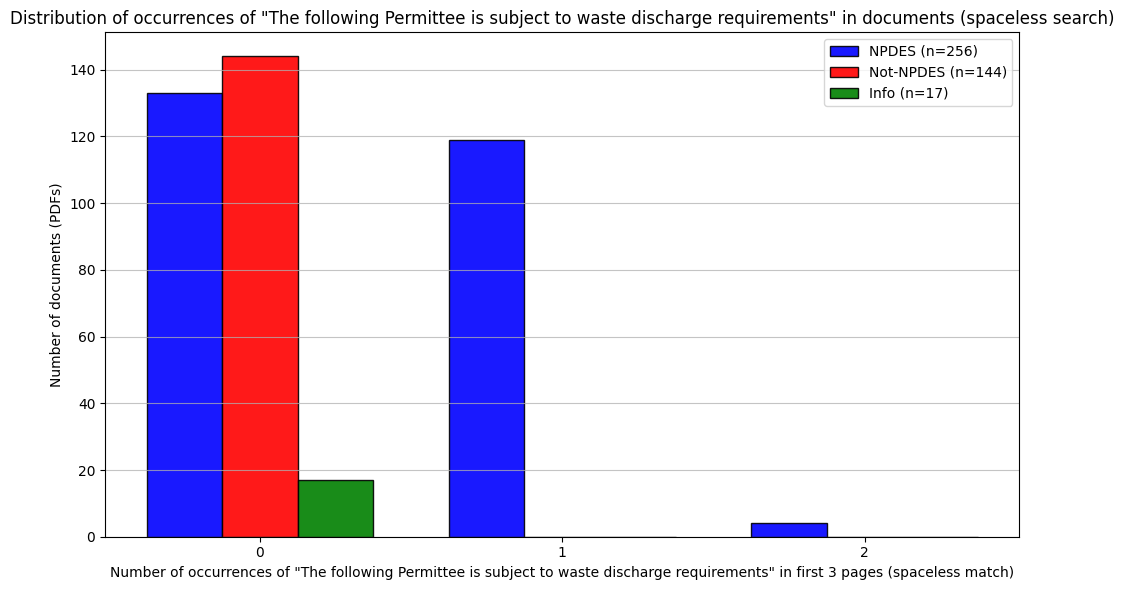

Saved histogram to output/2025-10-8-test1/The_following_Permittee_is_subject_to_waste_discharge_requirements_occurrences_histogram_spaceless.png


In [4]:
out_dir = 'output/2025-10-8-test1'
os.makedirs(out_dir, exist_ok=True)

word1 = 'The following Permittee is subject to waste discharge requirements'
print(f"Analyzing occurrences of the word: {word1}")
npdes_occurrences1 = search_keywords(path_npdes, word1, max_pages)
non_npdes_occurrences1 = search_keywords(path_non_npdes, word1, max_pages)
info_occurrences1 = search_keywords(path_info, word1, max_pages)
print(sum(npdes_occurrences1)/len(npdes_occurrences1))

word2 = 'The following Permittees are subject to waste discharge requirements'
print(f"Analyzing occurrences of the word: {word2}")
npdes_occurrences2 = search_keywords(path_npdes, word2, max_pages)
non_npdes_occurrences2 = search_keywords(path_non_npdes, word2, max_pages)
info_occurrences2 = search_keywords(path_info, word2, max_pages)
print(sum(npdes_occurrences2)/len(npdes_occurrences2))

word3 = 'The following Dischargers are subject to waste discharge requirements'
print(f"Analyzing occurrences of the word: {word3}")
npdes_occurrences3 = search_keywords(path_npdes, word3, max_pages)
non_npdes_occurrences3 = search_keywords(path_non_npdes, word3, max_pages)
info_occurrences3 = search_keywords(path_info, word3, max_pages)
print(sum(npdes_occurrences3)/len(npdes_occurrences3))

word4 = 'The following Discharger is subject to waste discharge requirements'
print(f"Analyzing occurrences of the word: {word4}")
npdes_occurrences4 = search_keywords(path_npdes, word4, max_pages)
non_npdes_occurrences4 = search_keywords(path_non_npdes, word4, max_pages)
info_occurrences4 = search_keywords(path_info, word4, max_pages)
print(sum(npdes_occurrences4)/len(npdes_occurrences4))

npdes_occurrences = [a + b + c + d for a, b, c, d in zip(npdes_occurrences1, npdes_occurrences2, npdes_occurrences3, npdes_occurrences4)]
non_npdes_occurrences = [a + b + c + d for a, b, c, d in zip(non_npdes_occurrences1, non_npdes_occurrences2, non_npdes_occurrences3, non_npdes_occurrences4)]
info_occurrences = [a + b + c + d for a, b, c, d in zip(info_occurrences1, info_occurrences2, info_occurrences3, info_occurrences4)]
analyze_and_plot(npdes_occurrences, non_npdes_occurrences, info_occurrences, word1, out_dir, max_pages)

In [16]:
for i, nb in enumerate (npdes_occurrences):
    if nb == 0:
        pdf_file_name = sorted(os.listdir(path_npdes))[i]
        print(f"NPDES PDF with zero occurrences: {pdf_file_name}")

NPDES PDF with zero occurrences: 20_0005_Samoa WWTF_NPDES.pdf
NPDES PDF with zero occurrences: 2848_R4-2021-0096_WDR_PKG.pdf
NPDES PDF with zero occurrences: 2960_R4-2022-0175_WDR_PKG.pdf
NPDES PDF with zero occurrences: 4993_R4-2022-0174_WDR_PKG.pdf
NPDES PDF with zero occurrences: 5059_R4-2021-0142_WDR_PKG (signed).pdf
NPDES PDF with zero occurrences: 8672_R4-2003-0141_FS.pdf
NPDES PDF with zero occurrences: ARC NPDES - Adopted  CI-10317 111623.pdf
NPDES PDF with zero occurrences: Adopted ECLWRF NPDES CI-7449 111623.pdf
NPDES PDF with zero occurrences: Adopted OWRRF NPDES CI-2022 06172024 signed.pdf
NPDES PDF with zero occurrences: AmendingOrderR920210199_Digitally Signed signed dwg 12-14-21 (1).pdf
NPDES PDF with zero occurrences: AmendingOrderR920210199_Digitally Signed signed dwg 12-14-21.pdf
NPDES PDF with zero occurrences: AmendingOrderR920210204_DigitalSignature signed dwg 12-17-21.pdf
NPDES PDF with zero occurrences: Benicia R2-2025-0001.pdf
NPDES PDF with zero occurrences: Bu

In [9]:
# plot the first page read through pypfd of a pdf file
def plot_first_page_pdf(file_path):
    try:
        with open(file_path, 'rb') as f:
            reader = PyPDF2.PdfReader(f)
            if len(reader.pages) > 0:
                page = reader.pages[0]
                text = page.extract_text()
                if text:
                    print(text[:3000])  # print first 3000 chars
                else:
                    print(f"No text extracted from the first page of {file_path}")
            else:
                print(f"No pages found in {file_path}")
    except Exception as e:
        print(f"Error reading or plotting first page of {file_path}: {e}")

plot_first_page_pdf('output/2025-10-8-test1/NPDES/10512_R4-2020-0053_WDR_PKG.pdf')

  ADOPTED ORDER (04/16/20)  CALIFORNIA REGIONAL WATER QUALITY CONTROL BOARD  
LOS ANGELES  REGION  
320 West 4th Street, Suite 200, Los Angeles, California 90013  
(213) 576 -6600   Fax (213) 576 -6660  
http://www.waterboards.ca.gov/losa ngeles/   
ORDER R4-2020-0053  
NPDES NO. CA0064670  
WASTE DISCHARGE REQUIREMENTS  
 FOR THE  LOS ANGELES COUNTY DEPARTMENT OF BEACHES AND HARBORS , 
ROYAL PALMS PUBLIC RESTROOM  
DISCHARGE TO THE PACIFIC OCEAN VIA THE JOINT WATER POLLUTION 
CONTROL PLANT   
The followi ng Discharger is subject to waste discharge requirements (WDR s) set forth in this 
Order:  
Table 1. Discharger Information  
Disc harger  Los Angeles County Department of Beaches and Harbors (Discharger  
or Permittee ) 
Name of F acility  Royal Palms Public Restroom  
Facility Address  2100 Paseo del Mar  
San Pedro, CA 90732  
Los Angeles County  
Table 2. Discharge Location  
Discharge 
Point  Effluent Description  Discharge 
Point 
Latitude  Discharge Point 
Longitu de Receivin